<img src="images/logo/selene-logo-640.png" style="max-height:75px;" alt="SELENE Logo" />

**Disclaimer:** This Jupyter Notebook contains content generated with the assistance of AI. While every effort has been made to review and validate the outputs, users should independently verify critical information before relying on it. The SELENE notebook repository is constantly evolving. We recommend downloading or pulling the latest version of this notebook from Github.

# The RMSProp Optimizer

Training neural networks is fundamentally an optimization problem, where the goal is to efficiently minimize a loss function over a high-dimensional and often ill-conditioned parameter space. While basic Gradient Descent provides a simple starting point, it is often insufficient in practice due to slow convergence, sensitivity to learning rates, and instability on complex loss surfaces. This has led to the development of a range of adaptive optimization methods designed to improve training efficiency and robustness.

**RMSProp** is one such method that plays a central role in modern deep learning optimization. It can be understood as combining two key ideas: the adaptive per-parameter scaling of AdaGrad and the smoothing behavior of Exponentially Weighted Moving Average (EWMA) momentum. By using an EWMA of squared gradients, RMSProp retains AdaGrad's ability to adjust learning rates based on gradient magnitudes, while avoiding AdaGrad's issue of monotonically decreasing learning rates that can stall training.

At the same time, RMSProp borrows the core intuition of EWMA momentum in the sense that it emphasizes recent gradient information rather than treating all past gradients equally. However, unlike classical momentum, RMSProp focuses on capturing gradient *scale* rather than gradient *direction*. This combination allows it to adapt step sizes dynamically while maintaining stability in the presence of noisy or rapidly changing gradients.

Understanding RMSProp is therefore important not only as a standalone optimizer, but also as a conceptual bridge between earlier methods like AdaGrad and momentum, and more advanced optimizers such as Adam. By studying RMSProp, one gains deeper insight into how modern optimization algorithms balance adaptation, stability, and convergence speed when training neural networks in practice.

### Setting up the Notebook

#### Make Required Imports

This notebook requires the import of different Python packages but also additional Python modules that are part of the repository. If a package is missing, use your preferred package manager (e.g., [conda](https://anaconda.org/anaconda/conda) or [pip](https://pypi.org/project/pip/)) to install it. If the code cell below runs with any errors, all required packages and modules have successfully been imported.

In [1]:
import numpy as np

from src.utils.plotting.gd import *

#### Preliminaries

* This notebook assumes a basic understanding of calculus and concepts of derivatives and partial derivatives.
* Although the notebook starts with a brief recap about EWMA momentum and AdaGrad, being already familiar with both algorithms is recommended.

---

## Quick Recap: Related Optimizers

RMSProp is best understood not as a completely new optimizer, but as a refinement that combines key ideas from both EWMA-style momentum and AdaGrad. Like AdaGrad, it adapts the learning rate for each parameter individually based on the magnitude of past gradients, effectively scaling updates to account for different parameter sensitivities. However, instead of accumulating all past squared gradients (which causes AdaGrad's learning rates to shrink monotonically), RMSProp uses an Exponentially Weighted moving Average (EWMA) of squared gradients &mdash; borrowing the core idea from momentum methods. This means it "forgets" older gradients and focuses on more recent ones, preventing the learning rate from decaying too aggressively while still benefiting from adaptive scaling.

In the following, we therefore provide a recap about EWMA Momentum and AdaGrad to highlight their respective strengths and weaknesses which then will help us to better understand the idea behind RMSProps. To illustrate their differences, we will implement all three optimizers to observe their behavior. Throughout this notebook we consider a multivariate function $f$ together with its derivative $g=f^\prime$ as a concrete example as defined below; we limit ourselves to only two inputs here to ease visualization, but all concepts apply to an arbitrary number of inputs.

$$
\begin{align}
\large f(x_1, x_2)\ &\large = 0.1x_1^2 + 5x_2^2\\[0.5em]
\large g(x_1, x_2)\ &\large = 0.2x_1 + 10x_2
\end{align}
$$

We also implement both functions as Python methods for testing all optimizer algorithms and visualize their results.

In [2]:
def f(x1, x2):
    return 0.1*(x1**2) + 5*(x2**2)

def g(x1, x2):
    return 0.2*x1, 10*x2

Before going further, let's first have a look at the function, using the provided auxiliary method `plot_multivariate_function(f)`.

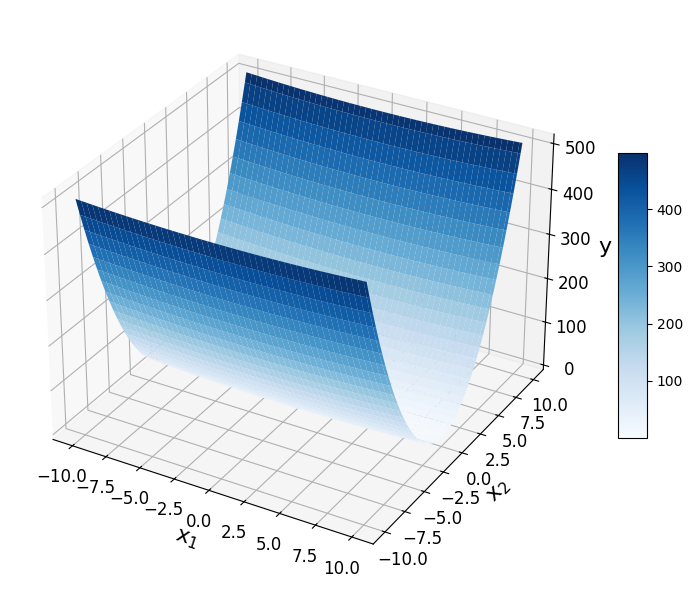

In [3]:
plot_multivariate_function(f)

Although we already know just from looking at the function $f$ that its minimum is at $x_1 = x_2 = 0$, this is not very obvious from the plot. The issues here is that function $f$, despite its simplicity, can be considered **ill-conditioned**. This means that small changes in its input or in the optimization process can lead to large and unstable changes in the output or in the path toward the minimum. In the context of optimization, this typically means that the function's curvature differs significantly across dimensions: in some directions the function changes very steeply, while in others it is relatively flat. Even for simple functions (e.g., quadratic forms), this can produce elongated, narrow valleys where the minimum lies, making it difficult for optimization algorithms to move efficiently toward the optimum.

To this function $f$, we will apply all three optimizers to find its minimum. For a fair comparison, we will be using the same initial choice of the parameters set at $x_1 = 9$ and $x_2 = -3$.

In [4]:
x0 = np.asarray([9, -3])

With the basic optimization task in place, let's briefly recap how EWMA momentum and AdaGrad works.

### EWMA Momentum

Exponentially Weighted Moving Average (EWMA) momentum is an extension of basic Gradient Descent that smooths parameter updates by incorporating a running average of past gradients. Instead of updating parameters solely based on the current gradient, EWMA maintains a "velocity" term $\mathbf{v}$ &mdash; an exponentially decaying average of previous gradients &mdash; so that recent gradients have more influence while older ones gradually fade. This velocity is then used to update the parameters, effectively introducing memory into the optimization process. Mathematically, EWMA momentum is defined as:

$$
\begin{align}
\large \mathbf{v}^{(t)}\ &\large = \beta\mathbf{v}^{(t-1)} + (1-\beta)g^{(t-1)}\\[0.5em]
\large \mathbf{\hat{v}}^{(t)}\ &\large = \frac{\mathbf{v}^{(t)}}{1 - \beta^t}\\[0.5em]
\large \mathbf{x}^{(t)}\ &\large = \mathbf{x}^{(t-1)} - \eta\cdot \mathbf{v}^{(t)}
\end{align}
$$

The hyperparameter  $\beta \in [0,1]$ (also sometimes called the momentum coefficient) controls how much of the past velocity is carried over to the current update. Its value is typically chosen in the range 0.5 to 0.99, with 0.9 a common default value, depending on the problem and the desired behavior. Lastly, $\eta$ denotes the learning rate, i.e., the scaling factor to (typically) scale down the gradients before the parameter update, just like in basic Gradient Descent. $\mathbf{\hat{v}}^{(t)}$ is the so-called bias correction term which is commonly applied. This addresses the consideration that we typically initialize $\mathbf{v}^{(0)} = \mathbf{0}$, meaning that in the early iterations the accumulated value is biased toward zero rather than reflecting the true scale of the gradients.

The core intuition is that basic Gradient Descent can be slow and unstable, especially in regions where the loss surface is noisy or ill-conditioned (e.g., steep in one direction and flat in another). EWMA momentum helps by dampening oscillations in directions where gradients frequently change sign, while accelerating progress in directions with consistent gradients. As a result, it leads to smoother, faster convergence and reduces the zig-zagging behavior often observed with plain Gradient Descent.

The method `ewma()` in the code cell below implements EWMA momentum. Note that the method returns the history of all parameter updates. While this is usually not required in practice, we can use this history to later plot the path the updates describe across the surface of the function.

In [5]:
def ewma(g, x, beta, eta, n_steps):
    # Initialize history of x values
    xs = [x]
    v = np.zeros_like(x)
    # Run basic Gradient Descent for n_steps iterations
    for t in range(n_steps):
        # Compute the gradient for current x values using derivative
        gradient = np.asarray(g(*x))
        # Update the velocity vector v
        v = beta*v + (1-beta)*gradient
        # Bias correction
        v_corrected = v / (1 - beta**(t+1))
        # Update x values based on gradient and learning rate
        x = x - eta*v_corrected
        # Add updated x values to history
        xs.append(x)
    # Return history of x values as a NumPy array
    return np.asarray(xs)

Let's run method `ewma()` to find the minimum of our example function for some default values for the hyperparameters, i.e., the momentum coefficient $\beta$, the learning rate $\eta$, and the total number of iterations we want to perform. Of course, you can change the hyperparameters to see how different values affect the final results.

In [6]:
beta, eta, n_steps = 0.9, 0.1, 100

xs_ewma = ewma(g, x0, beta, eta, n_steps)

`xs_ewma` contains all the parameter updates, which we can now pass to the auxiliary method `plot_gradient_descent_2d` to plot the path. Apart from the update history, the method also receives `f` to visualize the 2d function as contour plot, and `eta` for setting the title of the plot. Just run the code cell below to generate the animated plot (note that this might take a few seconds).

In [7]:
plot_gradient_descent_2d(f, xs_ewma, eta=eta, title=f"EWMA Momentum (η = {eta})")

As the plot shows, a key limitation of EWMA momentum is that the velocity term can become "too persistent", especially on ill-conditioned loss surfaces where curvature differs strongly across directions. Because the velocity is an exponentially averaged sum of past gradients, it does not immediately reflect sudden changes in the gradient direction. As a result, when the optimizer enters a region where the optimal direction shifts (e.g., near a narrow valley or steep curvature change), the accumulated momentum can keep pushing the parameters forward, causing overshooting or oscillations.

This happens because the EWMA update trades responsiveness for smoothness: it filters noise but also slows down adaptation. In ill-conditioned settings, where careful, direction-specific adjustments are required, this lag in adapting the velocity vector can lead to inefficient updates and instability, motivating more advanced methods that better balance memory and adaptivity.

### AdaGrad

AdaGrad is an adaptive optimization method that modifies basic Gradient Descent by assigning each parameter its own learning rate based on the history of past gradients. Instead of using a single global step size, AdaGrad accumulates the **sum of squared gradients** for each parameter and scales updates inversely proportional to this accumulation. This means parameters that have experienced large gradients in the past receive smaller updates, while those with smaller or infrequent gradients receive relatively larger updates. In the more detail, the two formulas underpinning AdaGrad are:

$$
\begin{align}
\large \mathbf{v}^{(t)}\ &\large = \mathbf{v}^{(t-1)} + \left[ g^{(t-1)} \right]^2\\[0.5em]
\large \mathbf{x}^{(t)}\ &\large = \mathbf{x}^{(t-1)} - \frac{\eta}{\sqrt{\mathbf{v}^{(t-1)} + \epsilon}}\odot g^{(t-1)}
\end{align}
$$

The core intuition is that in many problems &mdash; especially high-dimensional or sparse settings &mdash; different parameters can have very different sensitivities. Basic Gradient Descent treats all parameters equally, which can lead to inefficient progress on ill-conditioned loss surfaces. AdaGrad improves on this by automatically adapting the step size per parameter, leading to more balanced and stable updates, faster convergence in some cases, and particularly strong performance when dealing with sparse features.

Like EWMA momentum, we can directly implement AdaGrad as a simple Python method:

In [8]:
def adagrad(g, x0, eta, n_steps, epsilon=1e-8):
    # Initialize history of x values
    x, xs = x0, [x0]
    v = np.zeros_like(x)
    # Run basic Gradient Descent for n_steps iterations
    for _ in range(n_steps):
        # Compute the gradient for current x values using derivative
        gradient = np.asarray(g(*x))
        # Update sum of squared gradients
        v = v + gradient**2
        # Update x values based on gradient and learning rate
        x = x - (eta*gradient / (np.sqrt(v + epsilon)))
        # Add updated x values to history
        xs.append(x)
    # Return history of x values as a NumPy array
    return np.asarray(xs)

When running AdaGrad, we have to consider that the effective learning rate scales down instantly since the denominator (the sum of squared gradients) grows from the very first step. Thus, we can (and often should) start with a larger initial learning rate, one or even two orders of magnitude larger compared to basic Gradient Descent, incl. momentum methods such as EWMA momentum. In the code cell below, we therefore set $\eta=0.9$ by default, i.e., roughly $10$x the learning rate we used before when using the method `ewma()` to find the minimum.

In [9]:
eta, n_steps = 0.9, 100

xs_adagrad = adagrad(g, x0, eta, n_steps)

Using the method `plot_gradient_descent_2d()`, we can again plot the path reflecting the update history over all iterations.

In [10]:
plot_gradient_descent_2d(f, xs_adagrad, eta=eta, title=f"AdaGrad (η = {eta})")

Compared to EWMA momentum, AdaGrad is less prone to overshooting because it does not accumulate a directional "velocity" that can carry updates too far; instead, it scales each step directly based on the magnitude of past gradients. As gradients accumulate, AdaGrad's effective learning rates monotonically decrease, especially for parameters with consistently large gradients, leading to increasingly conservative updates. This built-in damping or "braking" effect naturally limits step sizes and reduces the risk of overshooting, even in ill-conditioned regions where momentum methods might continue pushing parameters past the optimum due to their inertia.

On the flip side, a limitation of AdaGrad is that it accumulates the sum of squared gradients over all past iterations, which continuously grows over time. As a result, the effective learning rates for each parameter monotonically decrease, eventually becoming extremely small. While this helps stabilize updates early on, it can cause the optimization process to slow down prematurely and even "stall" before reaching a good minimum, especially in long training runs or non-convex settings where continued learning is necessary.

---

## RMSProp Algorithm

In a nutshell, RMSProp combines the strengths of EWMA momentum and AdaGrad to address their individual shortcomings. Like AdaGrad, it adapts the learning rate for each parameter based on the magnitude of recent gradients, enabling more balanced updates across different dimensions. However, instead of accumulating all past squared gradients &mdash; which causes AdaGrad's learning rates to shrink indefinitely &mdash; RMSProp uses an exponentially weighted moving average (EWMA), similar in spirit to momentum methods, to focus on more recent gradient information. This allows RMSProp to retain adaptive scaling while preventing the learning rates from decaying too aggressively, leading to more stable and sustained learning over time.

### Definition & Implementation

RMSProps follows the main idea of AdaGrad, i.e., using the information about past gradients to implement parameter-specific learning rates instead of a single global one. However, in contrast to AdaGrad, RMSProps does not capture the information about past gradients merely as the sum of squared gradients. Instead, RMSPRops adopts EWMA momentum, i.e., an exponentially weighted moving average to capture the gradient history. Mathematically, RMSProp use the following formula to perform the parameter updates:

$$
\begin{align}
\large \mathbf{v}^{(t+1)}\ &\large = \beta\mathbf{v}^{(t)} + (1-\beta)\left[ g^{(t)} \right]^2\\[0.5em]
\large \mathbf{x}^{(t+1)}\ &\large = \mathbf{x}^{(t)} - \frac{\eta}{\sqrt{\mathbf{v}^{(t+1)} + \epsilon}}\odot g^{(t)}
\end{align}
$$

The formula clearly shows how RMSProps combines EWMA and AdaGrad. Note, however, that RMSProps maintains an exponentially weighted moving average (EWMA) of the **squared gradients** rather than the raw gradients. This means it is not tracking the direction in which parameters should move, but only the typical *magnitude* of those gradients for each parameter. In contrast, EWMA momentum averages the raw gradients themselves, which preserves directional information and builds a velocity vector that points toward consistently preferred update directions.

In practice, this distinction means RMSProp is primarily an **adaptive scaling method**, not a directional acceleration method. It uses the running estimate of gradient magnitude to shrink or enlarge the step size for each parameter, helping to stabilize updates in steep or noisy directions. However, since it does not encode direction, it cannot "push" updates forward the way momentum does, but it only modulates how big each step should be. 

Despite this fundamental difference, the implementation of AdaGrad can be directly derived from the implementations of EWMA and AdaGrad as seen above; see the method `rmsprop()` in the code cell below.

In [11]:
def rmsprop(g, x, beta, eta, n_steps, epsilon=1e-8):
    # Initialize history of x values
    xs = [x]
    v = np.zeros_like(x)
    # Run basic Gradient Descent for n_steps iterations
    for t in range(n_steps):
        # Compute the gradient for current x values using derivative
        gradient = np.asarray(g(*x))
        # Update the velocity vector v
        v = beta*v + (1-beta)*(gradient**2)
        # Update x values based on gradient and learning rate
        x = x - (eta*gradient / (np.sqrt(v + epsilon)))
        # Add updated x values to history
        xs.append(x)
    # Return history of x values as a NumPy array
    return np.asarray(xs)

Let's run the method `rmsprop()` for our example function using the same hyperparameter values as for AdaGrad. After all, RMSProp also scales down the learning rate from the first first iteration onwards, and we therefore should compensate for this by setting a larger learning rate compared to EWMA momentum (but also basic Gradient Descent).

In [12]:
beta, eta, n_steps = 0.9, 0.1, 100

xs_rmsprop = rmsprop(g, x0, beta, eta, n_steps)

Once again, we can now plot the update history to better understand the behavior of RMSProp.

In [13]:
plot_gradient_descent_2d(f, xs_rmsprop, eta=eta, title=f"RMSProp (η = {eta})")

While the update path of RMSProp looks quite similar to AdaGrad, the animation shows that RMSProp does not slow down as much as AdaGrad when getting closer to the minimum. This is because the exponentially weighted moving average computed by RMSprop does not lead to monotonically decreasing learning rates like in AdaGrad. As such, RMSProp is much less likely to "stall" before reaching the minimum.

In general, for simple functions &mdash; such as our example function here &mdash; with fairly consistent gradients, RMSProp and AdaGrad can behave quite similarly because the accumulation of squared gradients in AdaGrad and the EWMA in RMSProp both produce comparable scaling factors, leading to similar step sizes and convergence patterns. However, for more complex functions, especially those with changing curvature or non-stationary gradients, their behavior diverges significantly. AdaGrad keeps accumulating all past gradients, causing its learning rates to shrink continuously, while RMSProp "forgets" older information through its EWMA, allowing it to maintain more adaptive and responsive updates. This makes RMSProp better suited for navigating complex, evolving loss surfaces where sustained learning and quick adaptation are important.

### Discussion

RMSProp offers several key advantages by combining adaptive learning rates with controlled memory of past gradients. It scales updates per parameter based on recent gradient magnitudes, helping to handle ill-conditioned problems and reducing the need for careful manual tuning of a global learning rate. Unlike AdaGrad, it avoids the issue of monotonically shrinking learning rates by using an exponentially weighted moving average, allowing learning to continue effectively over long training periods. At the same time, it stabilizes updates and reduces oscillations in noisy or steep directions, leading to faster and more reliable convergence on complex loss surfaces.

Despite its advantages, RMSProps has its limitations, both theoretical and empirical &mdash; most importantly, these are:

* **No explicit momentum in parameter updates:** RMSProp adapts learning rates using an EWMA of squared gradients but does not maintain a true momentum term for the update direction like EWMA momentum, which can make it less effective at accelerating along consistent descent directions compared to methods like Adam or SGD with momentum.

* **Sensitivity to hyperparameters:** Performance can depend heavily on choices like the learning rate and decay rate. Poorly tuned settings may lead to unstable training or unnecessarily slow convergence.

* **Limited responsiveness to sudden changes:** Because it relies on an exponentially weighted average, RMSProp can still lag behind abrupt shifts in gradient behavior, especially in highly non-stationary or rapidly changing loss landscapes.

* **Potential generalization issues:** Like other adaptive optimizers, RMSProp may sometimes converge to solutions that generalize worse than those found by simpler methods such as SGD with momentum in certain deep learning settings.

The limitations of RMSProp motivate the development of more advanced optimizers like Adam, which aim to combine the strengths of both adaptive learning rate methods and momentum-based approaches. While RMSProp effectively adapts step sizes using an exponentially weighted average of squared gradients, it lacks a true momentum mechanism for stabilizing and accelerating updates in consistent directions. Adam addresses this by incorporating both first-moment (momentum-like) and second-moment (RMSProp-like) estimates, providing more robust and responsive updates across a wider range of optimization landscapes. This combination helps overcome issues such as slow adaptation, sensitivity to hyperparameters, and inconsistent convergence behavior seen in RMSProp.

---

## Summary

This notebook introduced the RMSProp optimizer as a key adaptive optimization method in machine learning, motivated by its connection to two foundational ideas: EWMA momentum and AdaGrad. Rather than treating RMSProp as an entirely separate algorithm, we interpreted it as a hybrid approach that combines AdaGrad's per-parameter adaptive learning rates with the smoothing behavior of exponentially weighted moving averages. To make these relationships concrete, we implemented Gradient Descent, AdaGrad, and RMSProp from scratch and compared their behavior on a simple example function.

Through these implementations, we observed how each optimizer updates parameters differently over time. Gradient Descent with momentum applies a fixed global learning rate, AdaGrad adapts learning rates based on the accumulation of past squared gradients, and RMSProp refines this idea by using an exponentially weighted average instead of a full accumulation. On simple convex or well-behaved functions, the differences in their trajectories can appear subtle, with all methods eventually converging to similar minima.

However, the real distinctions between these optimizers typically emerge only in more complex settings, such as the highly non-convex loss landscapes encountered when training deep neural networks. In such cases, factors like curvature variation, noise, and non-stationary gradients make adaptive scaling and stability mechanisms far more important. Exploring these scenarios in depth is beyond the scope of this introductory notebook, but they are crucial for understanding why modern optimizers behave differently in practice.

In summary, RMSProp offers strong practical advantages: it stabilizes training, adapts learning rates per parameter, and avoids the overly aggressive decay of AdaGrad. At the same time, it has limitations, including sensitivity to hyperparameters and the absence of explicit momentum in update directions. These shortcomings motivate more advanced optimizers such as Adam, which combine RMSProp-style adaptive scaling with momentum-based direction tracking to achieve more robust and efficient training in deep learning applications.